In [6]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

In [8]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')

# Set patient ID as index for easy matching
tissue_scores_indexed = tissue_scores.set_index("Name")


#plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [50]:
pred_pathways = ['REACTOME_ELASTIC_FIBRE_FORMATION', 'REACTOME_NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS','REACTOME_COLLAGEN_FORMATION','REACTOME_COLLAGEN_DEGRADATION','REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX','REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS','REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION']

In [51]:
def get_embeddings(type, fold):
    emb = torch.load(f'{type}/fold_{fold}_best_embeddings_proj.pt')
    if type=='embeddings_baseline':
        plasma_emb_list = emb["plasma"]

        patients = plasma_emb_list.keys()
        #patients = np.asarray(patients)
        print(patients)
    else:
        plasma_emb_list = emb["plasma"]['shared']
        patients = plasma_emb_list.keys()
        #patients = np.asarray(patients)
        print(patients)
     # concatenate embedding batches
    plasma_emb = torch.stack(
        list(plasma_emb_list.values())
    )
    if torch.is_tensor(plasma_emb):
        plasma_emb = plasma_emb.detach().cpu().numpy()

    return patients, plasma_emb

In [52]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr, spearmanr

In [53]:
import torch
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from scipy.stats import pearsonr, spearmanr

results = []
all_predictions = []


for test_fold in range(5):

    print(f"\n================ FOLD {test_fold} ================\n")

    # --------------------------------------------------------
    # Load test fold
    # --------------------------------------------------------

    test_patients, X_test = get_embeddings(
        "embeddings_orth_loss",       # change this later for other models
        test_fold
    )

    # --------------------------------------------------------
    # Load training folds
    # --------------------------------------------------------

    train_X = []
    train_patients = []

    for fold in range(5):

        if fold == test_fold:
            continue

        patients, embeddings = get_embeddings(
            "embeddings_orth_loss",
            fold
        )

        train_X.append(embeddings)
        train_patients.extend(patients)

    X_train = np.concatenate(train_X, axis=0)
    train_patients = np.asarray(train_patients)

    # --------------------------------------------------------
    # Match tissue pathway scores
    # --------------------------------------------------------

    train_scores = tissue_scores_indexed.loc[train_patients]
    print(train_scores)
    test_scores = tissue_scores_indexed.loc[test_patients]

    # --------------------------------------------------------
    # Predict each pathway independently
    # --------------------------------------------------------

    for pathway in pred_pathways:

        print(f"  {pathway}")

        y_train = train_scores[pathway].values.astype(float)
        y_test = test_scores[pathway].values.astype(float)

        # ----------------------------------------------------
        # Ridge model
        #
        # StandardScaler is fitted ONLY on training data.
        # ----------------------------------------------------

        model = make_pipeline(
            StandardScaler(),
            Ridge(alpha=1.0)
        )

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------

        r2 = r2_score(y_test, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_test, y_pred)
        )

        mae = mean_absolute_error(
            y_test,
            y_pred
        )

        # Pearson
        if np.std(y_test) > 0 and np.std(y_pred) > 0:
            pearson_r, pearson_p = pearsonr(
                y_test,
                y_pred
            )
        else:
            pearson_r, pearson_p = np.nan, np.nan

        # Spearman
        if np.std(y_test) > 0 and np.std(y_pred) > 0:
            spearman_r, spearman_p = spearmanr(
                y_test,
                y_pred
            )
        else:
            spearman_r, spearman_p = np.nan, np.nan

        # ----------------------------------------------------
        # Store metrics
        # ----------------------------------------------------

        results.append({
            "fold": test_fold,
            "pathway": pathway,
            "R2": r2,
            "RMSE": rmse,
            "MAE": mae,
            "Pearson_r": pearson_r,
            "Pearson_p": pearson_p,
            "Spearman_r": spearman_r,
            "Spearman_p": spearman_p
        })

        # ----------------------------------------------------
        # Store predictions
        # ----------------------------------------------------

        for patient, true, pred in zip(
            test_patients,
            y_test,
            y_pred
        ):

            all_predictions.append({
                "fold": test_fold,
                "patient": patient,
                "pathway": pathway,
                "true": true,
                "predicted": pred
            })


# ============================================================
# Convert to DataFrames
# ============================================================

results_df = pd.DataFrame(results)
predictions_df = pd.DataFrame(all_predictions)


================ FOLD 0 ================

dict_keys(['Sample 15', 'Sample 17', 'Sample 28', 'Sample 29', 'Sample 34', 'Sample 38', 'Sample 61', 'Sample 76', 'Sample 78', 'Sample 85', 'Sample 88'])
dict_keys(['Sample 16', 'Sample 18', 'Sample 22', 'Sample 31', 'Sample 49', 'Sample 51', 'Sample 64', 'Sample 65', 'Sample 70', 'Sample 79', 'Sample 87'])
dict_keys(['Sample 1', 'Sample 23', 'Sample 25', 'Sample 32', 'Sample 5', 'Sample 52', 'Sample 59', 'Sample 60', 'Sample 7', 'Sample 83'])
dict_keys(['Sample 11', 'Sample 12', 'Sample 42', 'Sample 48', 'Sample 57', 'Sample 66', 'Sample 73', 'Sample 75', 'Sample 82', 'Sample 86'])
dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])
           REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT  \
Name                                                         
Sample 16                                         0.080954   
Sample 18                             

In [54]:
def evaluate_embeddings(embedding_type, pred_pathways, tissue_scores):

    results = []
    predictions = []

    tissue_scores_indexed = tissue_scores.set_index("Name")

    for test_fold in range(5):

        # -------------------------------
        # Test fold
        # -------------------------------

        test_patients, X_test = get_embeddings(
            embedding_type,
            test_fold
        )

        # -------------------------------
        # Training folds
        # -------------------------------

        train_X = []
        train_patients = []

        for fold in range(5):

            if fold == test_fold:
                continue

            patients, embeddings = get_embeddings(
                embedding_type,
                fold
            )

            train_X.append(embeddings)
            train_patients.extend(patients)

        X_train = np.concatenate(train_X, axis=0)
        train_patients = np.asarray(train_patients)

        # -------------------------------
        # Tissue scores
        # -------------------------------

        train_scores = tissue_scores_indexed.loc[
            train_patients
        ]

        test_scores = tissue_scores_indexed.loc[
            test_patients
        ]

        # -------------------------------
        # Each pathway separately
        # -------------------------------

        for pathway in pred_pathways:

            y_train = train_scores[pathway].values.astype(float)
            y_test = test_scores[pathway].values.astype(float)

            model = make_pipeline(
                StandardScaler(),
                Ridge(alpha=1.0)
            )

            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            # metrics
            r2 = r2_score(y_test, y_pred)
            rmse = np.sqrt(
                mean_squared_error(y_test, y_pred)
            )
            mae = mean_absolute_error(
                y_test,
                y_pred
            )

            if np.std(y_test) > 0 and np.std(y_pred) > 0:

                pearson_r, pearson_p = pearsonr(
                    y_test,
                    y_pred
                )

                spearman_r, spearman_p = spearmanr(
                    y_test,
                    y_pred
                )

            else:
                pearson_r = pearson_p = np.nan
                spearman_r = spearman_p = np.nan

            results.append({
                "embedding": embedding_type,
                "fold": test_fold,
                "pathway": pathway,
                "R2": r2,
                "RMSE": rmse,
                "MAE": mae,
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_r": spearman_r,
                "Spearman_p": spearman_p
            })

            # save predictions
            for patient, true, pred in zip(
                test_patients,
                y_test,
                y_pred
            ):

                predictions.append({
                    "embedding": embedding_type,
                    "fold": test_fold,
                    "patient": patient,
                    "pathway": pathway,
                    "true": true,
                    "predicted": pred
                })

    return (
        pd.DataFrame(results),
        pd.DataFrame(predictions)
    )

In [57]:
all_results = []
all_predictions = []
embedding_types = {
    "Baseline": "embeddings_baseline",
    "Orthogonal": "embeddings_orth_loss",
    "Orthogonal + Recon": "embeddings_orth_recon",

}

for name, embedding_type in embedding_types.items():

    results, predictions = evaluate_embeddings(
        embedding_type,
        pred_pathways,
        tissue_scores
    )

    results["model"] = name
    predictions["model"] = name

    all_results.append(results)
    all_predictions.append(predictions)


results_df = pd.concat(
    all_results,
    ignore_index=True
)

predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

dict_keys(['Sample 15', 'Sample 17', 'Sample 28', 'Sample 29', 'Sample 34', 'Sample 38', 'Sample 61', 'Sample 76', 'Sample 78', 'Sample 85', 'Sample 88'])
dict_keys(['Sample 16', 'Sample 18', 'Sample 22', 'Sample 31', 'Sample 49', 'Sample 51', 'Sample 64', 'Sample 65', 'Sample 70', 'Sample 79', 'Sample 87'])
dict_keys(['Sample 1', 'Sample 23', 'Sample 25', 'Sample 32', 'Sample 5', 'Sample 52', 'Sample 59', 'Sample 60', 'Sample 7', 'Sample 83'])
dict_keys(['Sample 11', 'Sample 12', 'Sample 42', 'Sample 48', 'Sample 57', 'Sample 66', 'Sample 73', 'Sample 75', 'Sample 82', 'Sample 86'])
dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])
dict_keys(['Sample 16', 'Sample 18', 'Sample 22', 'Sample 31', 'Sample 49', 'Sample 51', 'Sample 64', 'Sample 65', 'Sample 70', 'Sample 79', 'Sample 87'])
dict_keys(['Sample 15', 'Sample 17', 'Sample 28', 'Sample 29', 'Sample 34', 'Sample 38', 'Sample 61', 'Sample 76

In [60]:
predictions_df.head()

,embedding,fold,patient,pathway,true,predicted,model
0,embeddings_baseline,0,Sample 15,REACTOME_ELASTIC_FIBRE_FORMATION,0.185673,0.150981,Baseline
1,embeddings_baseline,0,Sample 17,REACTOME_ELASTIC_FIBRE_FORMATION,0.120336,0.133419,Baseline
2,embeddings_baseline,0,Sample 28,REACTOME_ELASTIC_FIBRE_FORMATION,0.263842,0.189877,Baseline
3,embeddings_baseline,0,Sample 29,REACTOME_ELASTIC_FIBRE_FORMATION,0.077747,0.292868,Baseline
4,embeddings_baseline,0,Sample 34,REACTOME_ELASTIC_FIBRE_FORMATION,0.334097,0.154272,Baseline


In [63]:
summary = (
    results_df
    .groupby(["pathway","model"])
    [["R2", "RMSE", "MAE", "Pearson_r", "Spearman_r"]]
    .agg(["mean", "std"])
)

print(summary)

                                                                            R2  \
                                                                          mean   
pathway                                          model                           
REACTOME_COLLAGEN_DEGRADATION                    Baseline            -2.851446   
                                                 Orthogonal          -6.373732   
                                                 Orthogonal + Recon  -3.268652   
REACTOME_COLLAGEN_FORMATION                      Baseline            -2.012202   
                                                 Orthogonal         -10.850164   
                                                 Orthogonal + Recon  -4.985555   
REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX Baseline            -3.411850   
                                                 Orthogonal          -8.620204   
                                                 Orthogonal + Recon  -4.257481   
REACTOME_ELASTIC

In [59]:
oof_results = []

for pathway in pred_pathways:

    df = predictions_df[
        predictions_df["pathway"] == pathway
    ]

    y_true = df["true"].values
    y_pred = df["predicted"].values

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    pearson_r, pearson_p = pearsonr(
        y_true,
        y_pred
    )

    spearman_r, spearman_p = spearmanr(
        y_true,
        y_pred
    )

    oof_results.append({
        "pathway": pathway,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Pearson_r": pearson_r,
        "Pearson_p": pearson_p,
        "Spearman_r": spearman_r,
        "Spearman_p": spearman_p
    })

oof_results_df = pd.DataFrame(oof_results)

print(oof_results_df)

                                            pathway        R2      RMSE  \
0                  REACTOME_ELASTIC_FIBRE_FORMATION -7.137131  0.266711   
1   REACTOME_NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS -7.151158  0.207472   
2                       REACTOME_COLLAGEN_FORMATION -3.646043  0.157527   
3                     REACTOME_COLLAGEN_DEGRADATION -3.459045  0.166710   
4  REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX -4.225262  0.135871   
5       REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS -4.640589  0.124845   
6        REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION -5.985959  0.138785   

        MAE  Pearson_r  Pearson_p  Spearman_r  Spearman_p  
0  0.181925   0.059507   0.460562    0.009247    0.908783  
1  0.150588  -0.075879   0.346466   -0.081842    0.309775  
2  0.118899   0.082901   0.303538    0.116537    0.147399  
3  0.131129   0.063490   0.431045    0.076161    0.344671  
4  0.104812   0.023101   0.774691    0.016304    0.839907  
5  0.090230  -0.084589   0.293766   -0.

In [69]:
import os
import numpy as np
import pandas as pd
import torch

from scipy.stats import pearsonr, spearmanr
from sklearn.model_selection import KFold


# ============================================================
# SETTINGS
# ============================================================

embedding_types = {
    "Baseline": "embeddings_baseline",
    "Orthogonal": "embeddings_orth_loss",
    "Orthogonal + Recon": "embeddings_orth_recon",
}

embedding_filename = "fold_{fold}_best_embeddings_proj.pt"

tissue_scores_file = "PR80_30/tissue_pathway_scores.csv"

pred_pathways = [
    "REACTOME_ELASTIC_FIBRE_FORMATION",
    "REACTOME_NON_INTEGRIN_MEMBRANE_ECM_INTERACTIONS",
    "REACTOME_COLLAGEN_FORMATION",
    "REACTOME_COLLAGEN_DEGRADATION",
    "REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX",
    "REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS",
    "REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION",
    "REACTOME_ASSEMBLY_OF_COLLAGEN_FIBRILS_AND_OTHER_MULTIMERIC_STRUCTURES",
    "REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES",
    "REACTOME_ECM_PROTEOGLYCANS"
]

# Remove accidental whitespace
pred_pathways = [p.strip() for p in pred_pathways]


# ============================================================
# LOAD TISSUE PATHWAY SCORES
# ============================================================

tissue_scores = pd.read_csv(tissue_scores_file)

# Remove accidental whitespace from column names
tissue_scores.columns = tissue_scores.columns.str.strip()

# Make patient IDs strings
tissue_scores["Name"] = tissue_scores["Name"].astype(str)

# Check that all pathways exist
missing_pathways = [
    p for p in pred_pathways
    if p not in tissue_scores.columns
]

if missing_pathways:
    raise ValueError(
        f"These pathways were not found in tissue_scores:\n"
        f"{missing_pathways}"
    )


# ============================================================
# LOAD EMBEDDINGS
# ============================================================

def load_fold_embeddings(type, fold):

    emb = torch.load(f'{type}/fold_{fold}_best_embeddings_proj.pt')
    if type=='embeddings_baseline':
        plasma_emb_list = emb["plasma"]

        patients = plasma_emb_list.keys()
        #patients = np.asarray(patients)
        print(patients)
    else:
        plasma_emb_list = emb["plasma"]['shared']
        patients = plasma_emb_list.keys()
        #patients = np.asarray(patients)
        print(patients)
     # concatenate embedding batches
    plasma_emb = torch.stack(
        list(plasma_emb_list.values())
    )
    if torch.is_tensor(plasma_emb):
        plasma_emb = plasma_emb.detach().cpu().numpy()

    return patients, plasma_emb
    """
    Load the best projection embeddings for one fold.

    Expected structure:
        emb["plasma"] = {
            patient_id_1: tensor(...),
            patient_id_2: tensor(...),
            ...
        }

    Returns
    -------
    patient_ids : np.ndarray
    embeddings : np.ndarray
        Shape: (n_patients, embedding_dim)
    """



# ============================================================
# MATCH EMBEDDINGS TO TISSUE PATHWAY SCORES
# ============================================================

def match_embeddings_to_tissue(
    patient_ids,
    embeddings,
    tissue_scores,
    pathways
):
    """
    Match plasma embeddings and tissue pathway scores
    using patient IDs.
    """

    embedding_df = pd.DataFrame(
        embeddings,
        index=patient_ids,
        columns=[
            f"embedding_{i}"
            for i in range(embeddings.shape[1])
        ]
    )

    embedding_df.index.name = "Name"
    embedding_df = embedding_df.reset_index()

    tissue_subset = tissue_scores[
        ["Name"] + pathways
    ].copy()

    tissue_subset["Name"] = tissue_subset["Name"].astype(str)

    merged = pd.merge(
        embedding_df,
        tissue_subset,
        on="Name",
        how="inner"
    )

    embedding_columns = [
        c for c in embedding_df.columns
        if c.startswith("embedding_")
    ]

    return merged, embedding_columns


# ============================================================
# CORRELATION CALCULATION
# ============================================================

def calculate_correlations(
    merged,
    embedding_columns,
    pathways
):
    """
    Calculate Pearson and Spearman correlations between
    every embedding dimension and every tissue pathway.
    """

    results = []

    for pathway in pathways:

        for embedding_dim in embedding_columns:

            data = merged[
                [embedding_dim, pathway]
            ].dropna()

            n = len(data)

            if n < 3:
                pearson_r = np.nan
                pearson_p = np.nan
                spearman_rho = np.nan
                spearman_p = np.nan

            else:

                # Pearson
                pearson_r, pearson_p = pearsonr(
                    data[embedding_dim],
                    data[pathway]
                )

                # Spearman
                spearman_rho, spearman_p = spearmanr(
                    data[embedding_dim],
                    data[pathway]
                )

            results.append({
                "Pathway": pathway,
                "Embedding": embedding_dim,
                "N": n,
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_rho,
                "Spearman_p": spearman_p,
            })

    return pd.DataFrame(results)


# ============================================================
# MAIN ANALYSIS
# ============================================================

all_results = []
all_pooled_data = {}

for model_name, embedding_dir in embedding_types.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    model_fold_data = []

    for fold in range(5):

        print(f"\nFold {fold}")

        patient_ids, embeddings = load_fold_embeddings(
            embedding_dir,
            fold
        )

        print(
            f"Loaded {len(patient_ids)} patients "
            f"with embedding dimension {embeddings.shape[1]}"
        )

        merged, embedding_columns = match_embeddings_to_tissue(
            patient_ids,
            embeddings,
            tissue_scores,
            pred_pathways
        )

        print(
            f"Matched {len(merged)} patients "
            f"to tissue pathway scores"
        )

        # Calculate fold-level correlations
        fold_results = calculate_correlations(
            merged,
            embedding_columns,
            pred_pathways
        )

        fold_results["Model"] = model_name
        fold_results["Fold"] = fold

        all_results.append(fold_results)

        # Save data for pooled OOF analysis
        merged["Model"] = model_name
        merged["Fold"] = fold

        model_fold_data.append(merged)

    # Combine all five held-out folds
    all_pooled_data[model_name] = pd.concat(
        model_fold_data,
        ignore_index=True
    )


# ============================================================
# COMBINE FOLD RESULTS
# ============================================================

fold_results_df = pd.concat(
    all_results,
    ignore_index=True
)


# ============================================================
# POOLED OUT-OF-FOLD CORRELATIONS
# ============================================================

pooled_results = []

for model_name, data in all_pooled_data.items():

    embedding_columns = [
        c for c in data.columns
        if c.startswith("embedding_")
    ]

    for pathway in pred_pathways:

        for embedding_dim in embedding_columns:

            subset = data[
                [embedding_dim, pathway]
            ].dropna()

            n = len(subset)

            if n < 3:
                pearson_r = np.nan
                pearson_p = np.nan
                spearman_rho = np.nan
                spearman_p = np.nan

            else:

                pearson_r, pearson_p = pearsonr(
                    subset[embedding_dim],
                    subset[pathway]
                )

                spearman_rho, spearman_p = spearmanr(
                    subset[embedding_dim],
                    subset[pathway]
                )

            pooled_results.append({
                "Model": model_name,
                "Pathway": pathway,
                "Embedding": embedding_dim,
                "N": n,
                "Pearson_r": pearson_r,
                "Pearson_p": pearson_p,
                "Spearman_rho": spearman_rho,
                "Spearman_p": spearman_p,
            })


pooled_results_df = pd.DataFrame(pooled_results)


# ============================================================
# FIND STRONGEST EMBEDDING DIMENSION PER PATHWAY
# ============================================================

# For each model/pathway, identify the embedding dimension
# with the strongest absolute Pearson correlation.

best_pearson = (
    pooled_results_df
    .loc[
        pooled_results_df
        .groupby(["Model", "Pathway"])["Pearson_r"]
        .apply(lambda x: x.abs().idxmax())
    ]
    .reset_index(drop=True)
)

best_spearman = (
    pooled_results_df
    .loc[
        pooled_results_df
        .groupby(["Model", "Pathway"])["Spearman_rho"]
        .apply(lambda x: x.abs().idxmax())
    ]
    .reset_index(drop=True)
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n\n")
print("=" * 100)
print("STRONGEST PEARSON CORRELATION PER PATHWAY")
print("=" * 100)

print(
    best_pearson[
        [
            "Model",
            "Pathway",
            "Embedding",
            "N",
            "Pearson_r",
            "Pearson_p",
        ]
    ].to_string(index=False)
)


print("\n\n")
print("=" * 100)
print("STRONGEST SPEARMAN CORRELATION PER PATHWAY")
print("=" * 100)

print(
    best_spearman[
        [
            "Model",
            "Pathway",
            "Embedding",
            "N",
            "Spearman_rho",
            "Spearman_p",
        ]
    ].to_string(index=False)
)


# ============================================================
# SAVE RESULTS
# ============================================================

fold_results_df.to_csv(
    "embedding_tissue_correlations_per_fold.csv",
    index=False
)

pooled_results_df.to_csv(
    "embedding_tissue_correlations_pooled.csv",
    index=False
)

best_pearson.to_csv(
    "embedding_tissue_best_pearson.csv",
    index=False
)

best_spearman.to_csv(
    "embedding_tissue_best_spearman.csv",
    index=False
)


print("\nResults saved:")
print("  embedding_tissue_correlations_per_fold.csv")
print("  embedding_tissue_correlations_pooled.csv")
print("  embedding_tissue_best_pearson.csv")
print("  embedding_tissue_best_spearman.csv")


Baseline

Fold 0
dict_keys(['Sample 15', 'Sample 17', 'Sample 28', 'Sample 29', 'Sample 34', 'Sample 38', 'Sample 61', 'Sample 76', 'Sample 78', 'Sample 85', 'Sample 88'])
Loaded 11 patients with embedding dimension 32
Matched 11 patients to tissue pathway scores

Fold 1
dict_keys(['Sample 16', 'Sample 18', 'Sample 22', 'Sample 31', 'Sample 49', 'Sample 51', 'Sample 64', 'Sample 65', 'Sample 70', 'Sample 79', 'Sample 87'])
Loaded 11 patients with embedding dimension 32
Matched 11 patients to tissue pathway scores

Fold 2
dict_keys(['Sample 1', 'Sample 23', 'Sample 25', 'Sample 32', 'Sample 5', 'Sample 52', 'Sample 59', 'Sample 60', 'Sample 7', 'Sample 83'])
Loaded 10 patients with embedding dimension 32
Matched 10 patients to tissue pathway scores

Fold 3
dict_keys(['Sample 11', 'Sample 12', 'Sample 42', 'Sample 48', 'Sample 57', 'Sample 66', 'Sample 73', 'Sample 75', 'Sample 82', 'Sample 86'])
Loaded 10 patients with embedding dimension 32
Matched 10 patients to tissue pathway scores

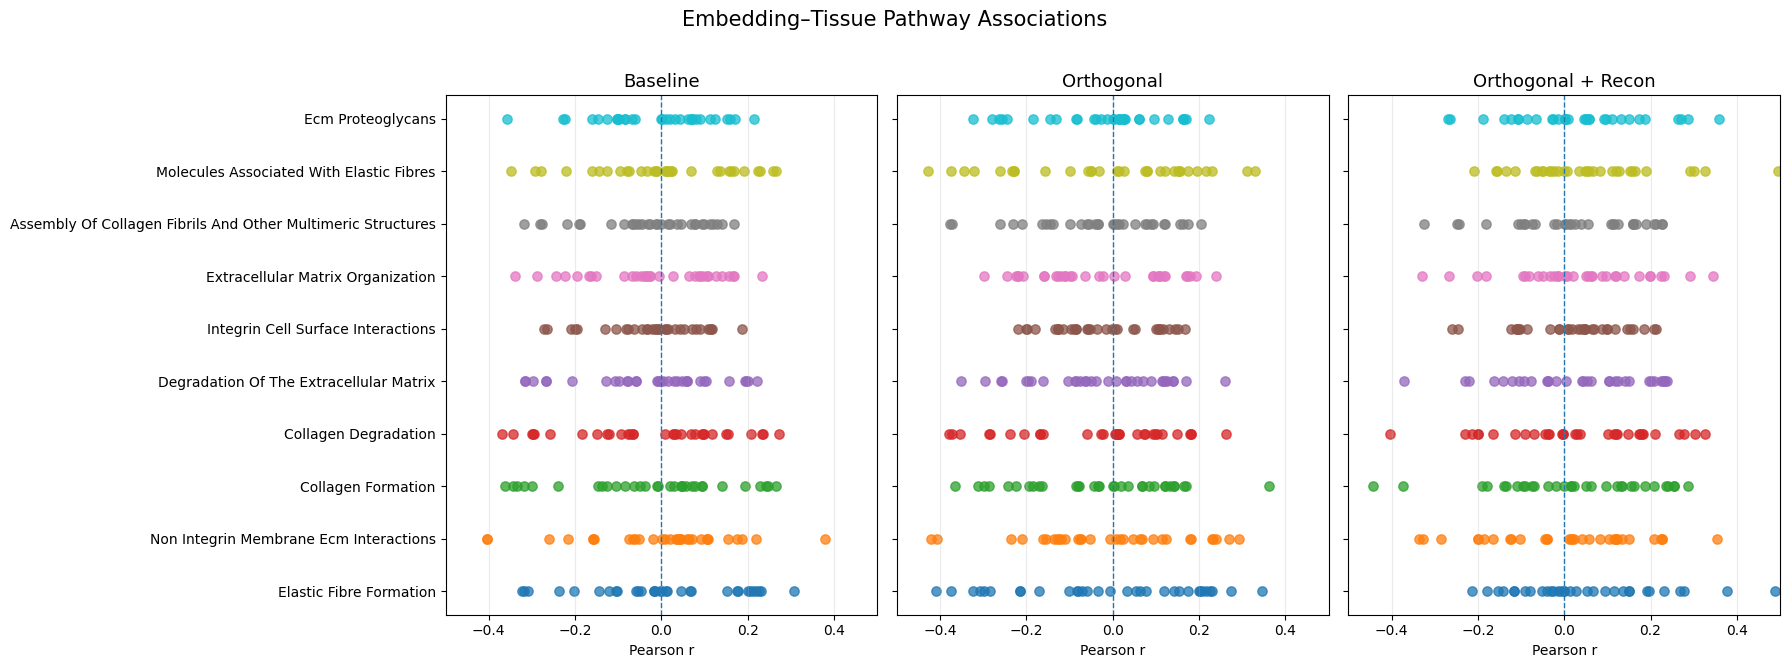

In [71]:
import matplotlib.pyplot as plt
def plot_embedding_correlations(
    results_df,
    pathways,
    correlation="Pearson_r",
    title=None
):

    df = results_df[
        results_df["Pathway"].isin(pathways)
    ].copy()

    if df.empty:
        print("No matching pathways found.")
        return

    models = [
        "Baseline",
        "Orthogonal",
        "Orthogonal + Recon"
    ]

    # Get embedding number
    df["Embedding_number"] = (
        df["Embedding"]
        .str.extract(r"(\d+)")
        .astype(int)
    )

    # Order pathways according to supplied list
    pathway_order = [
        p for p in pathways
        if p in df["Pathway"].unique()
    ]

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(18, max(5, len(pathway_order) * 0.65)),
        sharey=True
    )

    if len(models) == 1:
        axes = [axes]

    # Determine common x-axis
    max_abs_r = np.nanmax(
        np.abs(df[correlation].values)
    )

    x_limit = max(0.4, np.ceil(max_abs_r * 10) / 10)

    for ax, model in zip(axes, models):

        model_df = df[
            df["Model"] == model
        ].copy()

        for pathway_idx, pathway in enumerate(pathway_order):

            pathway_df = model_df[
                model_df["Pathway"] == pathway
            ].sort_values("Embedding_number")

            x = pathway_df["Embedding_number"].values
            y = pathway_df[correlation].values

            # Small vertical offset so overlapping points
            # remain visible
            y_position = np.full(
                len(x),
                pathway_idx
            )

            # Scatter
            ax.scatter(
                y,
                y_position,
                s=45,
                alpha=0.75
            )

        # Zero reference
        ax.axvline(
            0,
            linestyle="--",
            linewidth=1
        )

        ax.set_xlim(
            -x_limit,
            x_limit
        )

        ax.set_title(
            model,
            fontsize=13
        )

        ax.set_xlabel(
            "Pearson r" if correlation == "Pearson_r"
            else "Spearman ρ"
        )

        ax.set_yticks(
            range(len(pathway_order))
        )

        if ax == axes[0]:
            ax.set_yticklabels(
                [
                    p.replace("REACTOME_", "")
                     .replace("_", " ")
                     .title()
                    for p in pathway_order
                ]
            )
        else:
            ax.tick_params(
                axis="y",
                labelleft=False
            )

        ax.grid(
            axis="x",
            alpha=0.25
        )

    if title is not None:
        fig.suptitle(
            title,
            fontsize=15,
            y=1.02
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# PLOT PEARSON
# ============================================================
# Make sure pathway names match
pooled_results_df["Pathway"] = pooled_results_df["Pathway"].str.strip()

plot_embedding_correlations(
    pooled_results_df,
    pred_pathways,
    correlation="Pearson_r",
    title="Embedding–Tissue Pathway Associations"
)

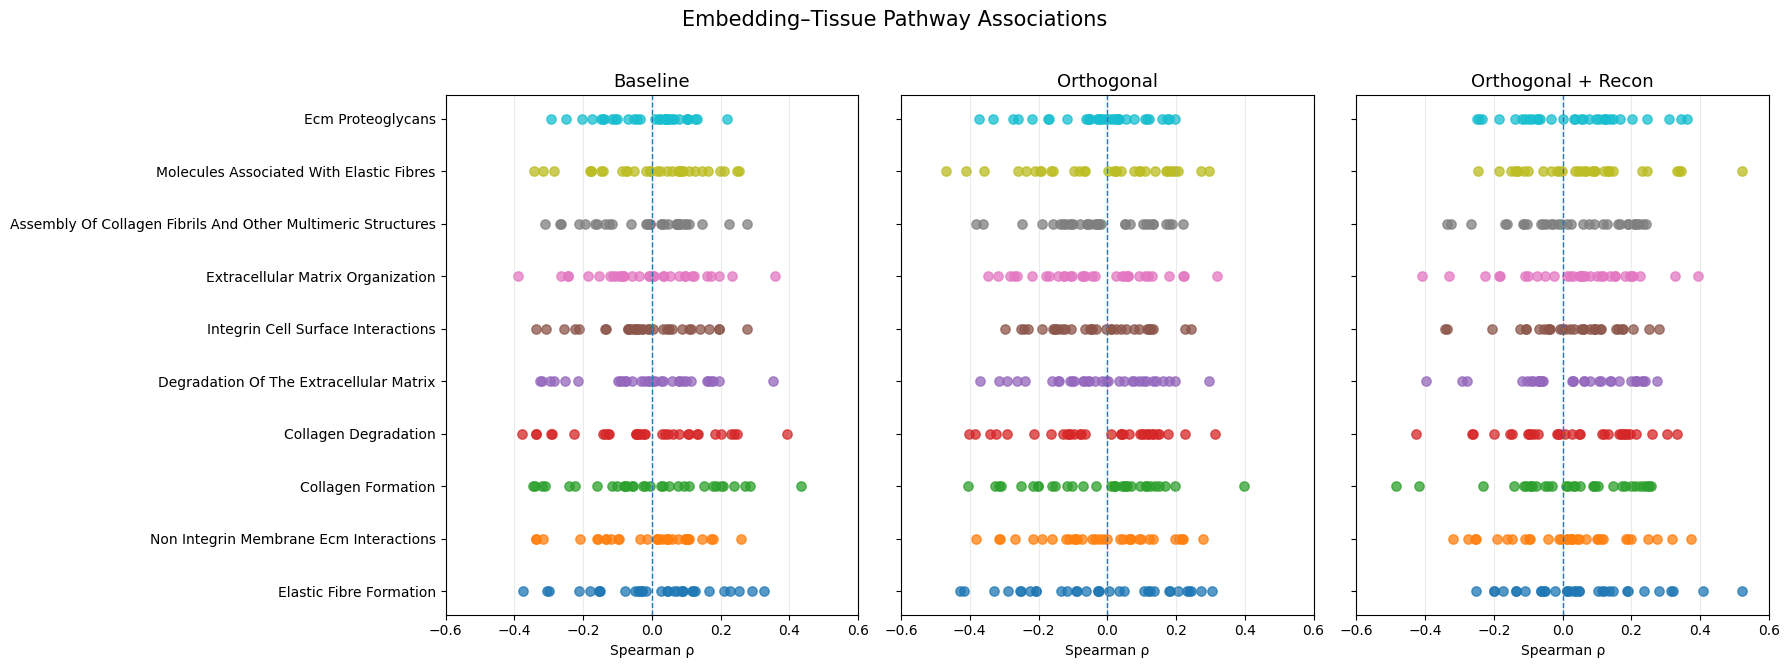

In [72]:
plot_embedding_correlations(
    pooled_results_df,
    pred_pathways,
    correlation="Spearman_rho",
    title="Embedding–Tissue Pathway Associations"
)

In [67]:
print(pooled_results_df.head())

      Model                           Pathway    Embedding   N  Pearson_r  \
0  Baseline  REACTOME_ELASTIC_FIBRE_FORMATION  embedding_0  52  -0.018174   
1  Baseline  REACTOME_ELASTIC_FIBRE_FORMATION  embedding_1  52  -0.102384   
2  Baseline  REACTOME_ELASTIC_FIBRE_FORMATION  embedding_2  52  -0.202746   
3  Baseline  REACTOME_ELASTIC_FIBRE_FORMATION  embedding_3  52  -0.317538   
4  Baseline  REACTOME_ELASTIC_FIBRE_FORMATION  embedding_4  52   0.152226   

   Pearson_p  Spearman_rho  Spearman_p  
0   0.898244      0.072398    0.610016  
1   0.470140     -0.030137    0.832037  
2   0.149443     -0.155041    0.272425  
3   0.021799     -0.374029    0.006304  
4   0.281335      0.090498    0.523450  


In [68]:
# ============================================================
# AGGREGATE CORRELATIONS ACROSS EMBEDDING DIMENSIONS
# ============================================================

aggregated_results = (
    pooled_results_df
    .groupby(["Model", "Pathway"])
    .agg(
        Mean_Pearson_r=("Pearson_r", "mean"),
        Mean_Abs_Pearson_r=("Pearson_r", lambda x: np.mean(np.abs(x))),
        Mean_Spearman_rho=("Spearman_rho", "mean"),
        Mean_Abs_Spearman_rho=("Spearman_rho", lambda x: np.mean(np.abs(x))),
    )
    .reset_index()
)

# Optional: round for easier viewing
aggregated_results = aggregated_results.round(3)

print("\n")
print("=" * 100)
print("AGGREGATED CORRELATIONS ACROSS EMBEDDING DIMENSIONS")
print("=" * 100)

print(
    aggregated_results.to_string(index=False)
)

# Save
aggregated_results.to_csv(
    "embedding_tissue_correlations_aggregated.csv",
    index=False
)



AGGREGATED CORRELATIONS ACROSS EMBEDDING DIMENSIONS
             Model                                          Pathway  Mean_Pearson_r  Mean_Abs_Pearson_r  Mean_Spearman_rho  Mean_Abs_Spearman_rho
          Baseline                    REACTOME_COLLAGEN_DEGRADATION          -0.027               0.149             -0.013                  0.152
          Baseline                      REACTOME_COLLAGEN_FORMATION          -0.024               0.143             -0.000                  0.159
          Baseline REACTOME_DEGRADATION_OF_THE_EXTRACELLULAR_MATRIX          -0.023               0.121             -0.014                  0.127
          Baseline                 REACTOME_ELASTIC_FIBRE_FORMATION           0.007               0.137              0.007                  0.139
          Baseline       REACTOME_EXTRACELLULAR_MATRIX_ORGANIZATION          -0.018               0.120             -0.016                  0.126
          Baseline      REACTOME_INTEGRIN_CELL_SURFACE_INTERACTIONS   